# Accuracy, Precision, Recall, Specificity, F1-score(trường hợp đặc biệt của Fβ-score), ..

Accuracy: Trong tất cả các thằng → ta đoán đúng được bao nhiêu.
$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$

Precision: Trong những thằng ta đoán là đúng (Positive) → thực sự đúng được bao nhiêu.
$$Precision=\frac{TP}{TP+FP}$$

Recall / Sensitivity: Trong những thằng thực tế là đúng (Positive) → ta tìm/đoán đúng được bao nhiêu.
$$Recall=\frac{TP}{TP+FN}$$

Specificity: Trong những thằng thực tế là sai (Negative) → ta đoán đúng là sai được bao nhiêu.
$$Specificity=\frac{TN}{TN+FP}$$

F1-score: Đo mức độ cân bằng giữa Precision và Recall → cả hai cùng cao thì F1 cao.
$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$
$$
\boxed{F1\ càng\ gần\ 1\rightarrow càng\ tốt}
$$

Fβ-score: Giống F1 nhưng cho phép ưu tiên Precision hoặc Recall hơn.
$$
F_\beta=(1+\beta^2)
\frac{Precision\times Recall}
{\beta^2Precision+Recall}
$$
- \(\beta=1\) → cân bằng Precision và Recall → chính là F1
- \(\beta>1\) → ưu tiên Recall
- \(\beta<1\) → ưu tiên Precision  

ROC curve:
- thresold: ngưỡng quyết định ý là nó quyết định từ nào trở lên là 1 như với sigmoid là từ 0->1 là chọn >0.7 là 1 thì cái 0.7 đó gọi là thresold

Khi thay đổi Threshold, Sensitivity (Recall) và Specificity cũng thay đổi:

$$Sensitivity=\frac{TP}{TP+FN}$$

$$Specificity=\frac{TN}{TN+FP}$$
ROC Curve biểu diễn:

$$\boxed{Y = Sensitivity}$$
và trục X thường viết dưới dạng:

$$\boxed{X = 1-Specificity}$$
tức là:

$$1-Specificity=\frac{FP}{FP+TN}$$


### 📌 Mẹo nhớ bản chất đường cong ROC (Receiver Operating Characteristic)

* **Trục Y (TPR / Recall / Sensitivity):** Trong những ca thực tế là **ĐÚNG (Positive)** $\to$ đoán **ĐÚNG** được bao nhiêu.
  $$TPR = \frac{TP}{TP + FN}$$

* **Trục X (FPR):** Trong những ca thực tế là **SAI (Negative)** $\to$ đoán **NHẦM thành ĐÚNG** bao nhiêu.
  $$FPR = \frac{FP}{FP + TN}$$

---

#### 💡 Công thức ghi nhớ siêu ngắn:
$$\boxed{Y = \text{Đúng thật} \to \text{Đoán đúng}}$$
$$\boxed{X = \text{Sai thật} \to \text{Đoán nhầm thành đúng}}$$

> **Quy tắc:** ROC càng phồng về **góc trên - trái $(0, 1)$** càng tốt: **$Y$ cực đại** (bắt trọn ca đúng) và **$X$ cực tiểu** (không báo động giả).

### AUC
AUC = Area Under the Curve = diện tích nằm dưới đường ROC Curve.
Nó biến cả đường ROC thành một con số để dễ đánh giá/so sánh model:
$$
\boxed{AUC = \text{diện tích dưới ROC Curve}}
$$

AUC càng gần 1 → khả năng phân biệt 2 class của model càng tốt.  
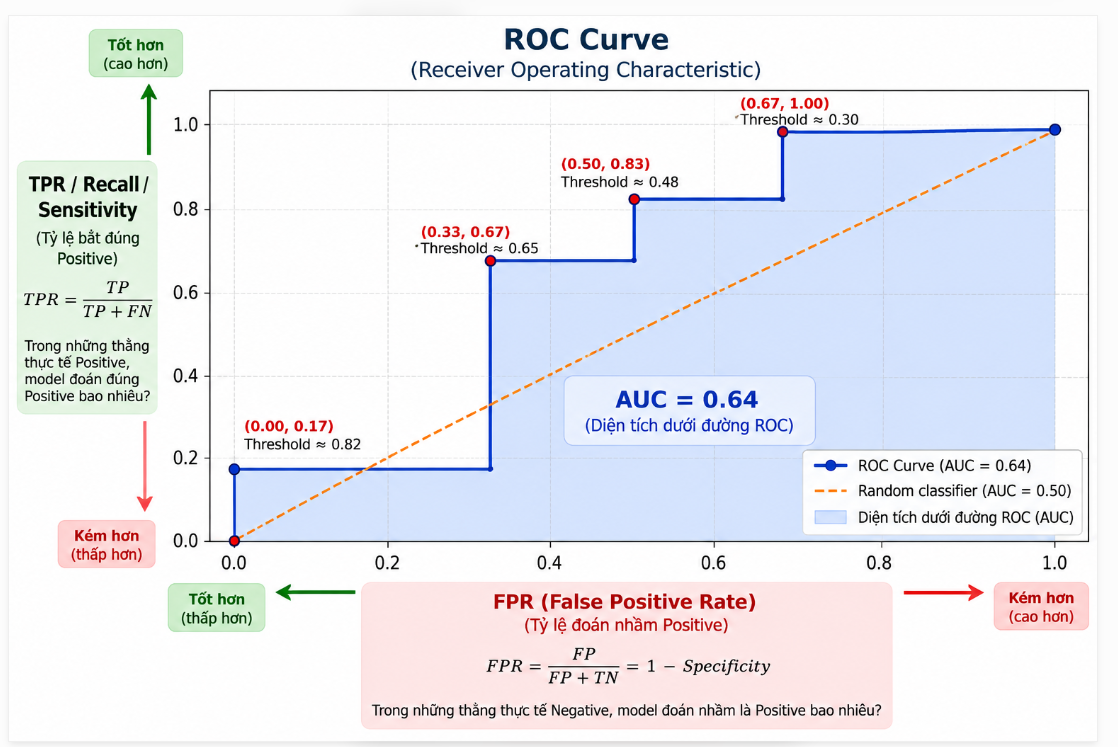

===== PREDICTION =====
Actual:      [0 1 1 0 1 0 1 0 0 0 1 1]
Prediction:  [0 1 0 0 0 0 1 1 1 0 0 1]
Probability: [0.397 0.876 0.458 0.237 0.367 0.339 0.612 0.846 0.641 0.26  0.285 0.52 ]

===== CONFUSION MATRIX =====
[[4 2]
 [3 3]]

TP: 3
TN: 4
FP: 2
FN: 3

===== METRICS =====
Accuracy:     0.583
Precision:    0.6
Recall:       0.5
Sensitivity:  0.5
Specificity:  0.667
F1-score:     0.545
F2-score:     0.517
F0.5-score:   0.577

===== ROC =====
FPR:        [0.    0.    0.333 0.333 0.5   0.5   0.667 0.667 1.   ]
TPR:        [0.    0.167 0.167 0.667 0.667 0.833 0.833 1.    1.   ]
Thresholds: [  inf 0.876 0.641 0.458 0.397 0.367 0.339 0.285 0.237]

AUC: 0.639


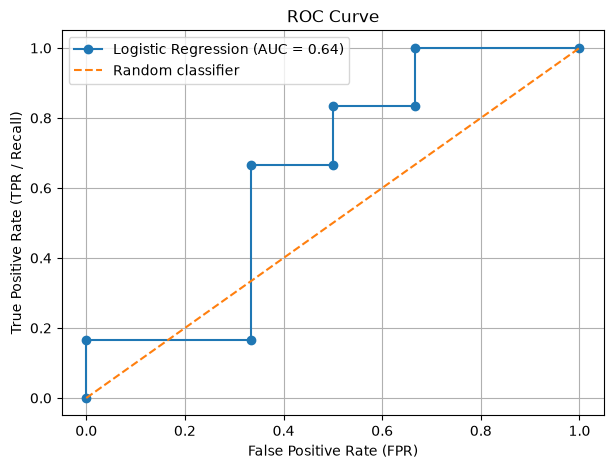

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_curve,
    roc_auc_score
)


# ============================================================
# 1. TẠO DATA
# ============================================================

# X: giả sử là một chỉ số xét nghiệm
X = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10],
    [11], [12], [13], [14], [15],
    [16], [17], [18], [19], [20],
    [21], [22], [23], [24], [25],
    [26], [27], [28], [29], [30]
])

# 0 = Không bệnh (Negative)
# 1 = Bị bệnh    (Positive)
#
# Cố tình tạo dữ liệu chồng lấn để model có dự đoán sai
y = np.array([
    0, 0, 0, 1, 0,
    0, 1, 0, 0, 1,
    0, 1, 1, 0, 1,
    0, 1, 1, 0, 1,
    1, 0, 1, 1, 0,
    1, 1, 0, 1, 1
])


# ============================================================
# 2. CHIA TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)


# ============================================================
# 3. TRAIN LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression()

model.fit(X_train, y_train)


# ============================================================
# 4. PREDICT
# ============================================================

# Kết quả phân loại cuối cùng: 0 hoặc 1
y_pred = model.predict(X_test)

# Xác suất thuộc class 1
y_prob = model.predict_proba(X_test)[:, 1]


print("===== PREDICTION =====")

print("Actual:     ", y_test)
print("Prediction: ", y_pred)
print("Probability:", np.round(y_prob, 3))


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\n===== CONFUSION MATRIX =====")

print(cm)

print("\nTP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)


# ============================================================
# 6. ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

# Accuracy = (TP + TN) / Total


# ============================================================
# 7. PRECISION
# ============================================================

precision = precision_score(y_test, y_pred)

# Precision = TP / (TP + FP)
#
# Trong những thằng ta đoán là Positive
# -> thực sự Positive bao nhiêu?


# ============================================================
# 8. RECALL / SENSITIVITY
# ============================================================

recall = recall_score(y_test, y_pred)

# Recall = TP / (TP + FN)
#
# Trong những thằng thực tế Positive
# -> ta tìm đúng được bao nhiêu?

sensitivity = recall


# ============================================================
# 9. SPECIFICITY
# ============================================================

specificity = tn / (tn + fp)

# Specificity = TN / (TN + FP)
#
# Trong những thằng thực tế Negative
# -> ta đoán đúng là Negative bao nhiêu?


# ============================================================
# 10. F1 SCORE
# ============================================================

f1 = f1_score(y_test, y_pred)

# F1:
# cân bằng Precision và Recall


# ============================================================
# 11. F-BETA SCORE
# ============================================================

# beta > 1 -> ưu tiên Recall
f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2
)

# beta < 1 -> ưu tiên Precision
f05 = fbeta_score(
    y_test,
    y_pred,
    beta=0.5
)


# ============================================================
# 12. IN TẤT CẢ METRIC
# ============================================================

print("\n===== METRICS =====")

print("Accuracy:    ", round(accuracy, 3))
print("Precision:   ", round(precision, 3))
print("Recall:      ", round(recall, 3))
print("Sensitivity: ", round(sensitivity, 3))
print("Specificity: ", round(specificity, 3))
print("F1-score:    ", round(f1, 3))
print("F2-score:    ", round(f2, 3))
print("F0.5-score:  ", round(f05, 3))


# ============================================================
# 13. ROC CURVE
# ============================================================

# ROC dùng xác suất, KHÔNG dùng y_pred
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n===== ROC =====")

print("FPR:       ", np.round(fpr, 3))
print("TPR:       ", np.round(tpr, 3))
print("Thresholds:", np.round(thresholds, 3))

print("\nAUC:", round(auc, 3))


# ============================================================
# 14. VẼ ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    marker="o",
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

# Đường random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()